In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd

burial_tables = pd.read_excel(
    "archy494data.xlsx",
    sheet_name="burialtables",
    skiprows=2
)

print(burial_tables.columns.tolist())

['Site', 'Sub-region', 'Adult Burials', 'Intramural', 'Extramural', 'Unknown Context', 'Pithos Burials', 'Cist Grave', 'Simple Internment', 'Refuse Pit', 'Other', 'Unknown', 'Notes']


In [3]:
burial_tables.columns = (
    burial_tables.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [4]:
import pandas as pd
import numpy as np

cols = [
    "adult_burials", "intramural", "extramural", "pithos_burials",
    "simple_internment", "refuse_pit", "other", "unknown"
]

burial_tables2 = burial_tables.copy()

# Drop embedded header rows
burial_tables2 = burial_tables2[burial_tables2["site"].ne("Site")].copy()

# Convert numeric columns safely
burial_tables2[cols] = (
    burial_tables2[cols]
    .replace("-", 0)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)


/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_32301/79316401.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("-", 0)


In [5]:
import pandas as pd
import numpy as np

df = burial_tables.copy()
s = df["site"].astype(str)

is_subadult_marker = s.str.contains("Subadult", case=False, na=False)
df["age_group"] = np.where(is_subadult_marker.cumsum() > 0, "Subadult", "Adult")
df["age_group"] = df["age_group"].astype(str).str.strip()   # <-- normalize

bad_sites = {"Site", "Adults", "Subadults", "Table 1: Adult Burials", "Table 2: Subadult Burials"}
df = df[~df["site"].isin(bad_sites)].copy()
df = df.dropna(subset=["site", "sub_region"])

df["total"] = pd.to_numeric(df["adult_burials"].replace({"-": 0}), errors="coerce")
df = df.dropna(subset=["total"])

# Pivot
wide = df.pivot_table(
    index=["site", "sub_region"],
    columns="age_group",
    values="total",
    aggfunc="sum"
)

print("Pivot columns:", list(wide.columns))  # <-- you can delete once confirmed

# Guarantee both columns exist, in a fixed order
wide = wide.reindex(columns=["Adult", "Subadult"])

totals = wide.rename(columns={"Adult": "adult_total", "Subadult": "subadult_total"}).reset_index()

totals[["adult_total", "subadult_total"]] = totals[["adult_total", "subadult_total"]].fillna(0).astype(int)

totals.sort_values(["sub_region", "site"]).head(20)


Pivot columns: ['Adult', 'Subadult']


/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_32301/3549533122.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["total"] = pd.to_numeric(df["adult_burials"].replace({"-": 0}), errors="coerce")


age_group,site,sub_region,adult_total,subadult_total
6,Canhasan,Konya Plain,6,10
11,Kubad Abad,Konya Plain,0,2
17,Çatal Höyük West,Konya Plain,0,2
0,Alaca Höyük,Kızılırmak Curve,1,5
1,Alişar Höyük,Kızılırmak Curve,24,8
3,Boğazköy-Büyükkaya,Kızılırmak Curve,0,1
4,Boğazköy-Yarıkkaya,Kızılırmak Curve,0,0
5,Büyük Güllücek,Kızılırmak Curve,1,0
9,Kalınkaya-Toptaştepe,Kızılırmak Curve,16,18
13,Orman Fidanlığı,Kızılırmak Curve,0,1


In [6]:
df.groupby("age_group")["total"].count()

age_group
Adult       11
Subadult    17
Name: total, dtype: int64

In [7]:
analysis_df = totals.merge(
    burial_tables[[
        "site",
        "intramural",
        "extramural",
        "pithos_burials",
        "simple_internment",
        "refuse_pit",
        "other",
        "unknown"
    ]],
    on="site",
    how="left"
)

analysis_df = analysis_df.replace("-", 0) #maybe messing with correlation
analysis_df = analysis_df.apply(pd.to_numeric, errors="ignore")

/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_32301/3403051561.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  analysis_df = analysis_df.replace("-", 0) #maybe messing with correlation
/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_32301/3403051561.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  analysis_df = analysis_df.apply(pd.to_numeric, errors="ignore")


### make colormap

In [8]:
from matplotlib.colors import LinearSegmentedColormap

colors = ["#643690"
          , "#35303C"
          , "#000000"
          , "#7E5C0A"
          , "#FCB813"]

husky_cmap = LinearSegmentedColormap.from_list("burialmap", colors)

husky_cmap = LinearSegmentedColormap.from_list("burialmap", colors[::-1])



### testing cmap

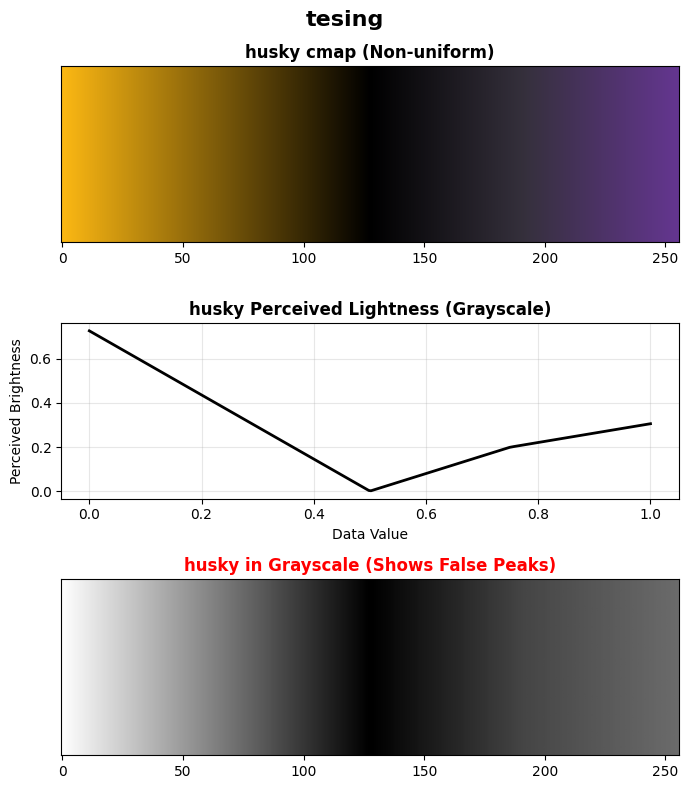

In [9]:
#create data
# Create data
x = np.linspace(0, 1, 256)
gradient = x.reshape(1, -1)

# plot
fig, axes = plt.subplots(3, 1, figsize=(7, 8))

# husky colormap
axes[0].imshow(gradient, cmap=husky_cmap, aspect='auto')
axes[0].set_title('husky cmap (Non-uniform)', size=12, weight='bold')
axes[0].set_yticks([])

# Extracting perceived brightness from husky colormap
husky_colors = husky_cmap(x)
husky_gray = np.dot(husky_colors[:,:3], [0.299, 0.587, 0.114])  # RGB to grayscale
# The dot product computes for each color value its (perceived brightness) grayscale = 0.299×R + 0.587×G + 0.114×B
axes[1].plot(x, husky_gray, 'k-', lw=2)
axes[1].set_title('husky Perceived Lightness (Grayscale)', size=12, weight='bold')
axes[1].set_xlabel('Data Value')
axes[1].set_ylabel('Perceived Brightness')
axes[1].grid(True, alpha=0.3)

# husky converted to grayscale image (two peaks)
axes[2].imshow(np.tile(husky_gray, (10, 1)), cmap='gray', aspect='auto')
axes[2].set_title('husky in Grayscale (Shows False Peaks)', size=12, weight='bold', color='red')
axes[2].set_yticks([])

plt.suptitle('tesing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Making the matrix

In [10]:
corr = analysis_df.select_dtypes("number").corr()
#Trimming becasue I will be masking the cells with corr coef <= 0 as well as redundant cells leaving blank space
corr_trim = corr.iloc[1:, 2:]

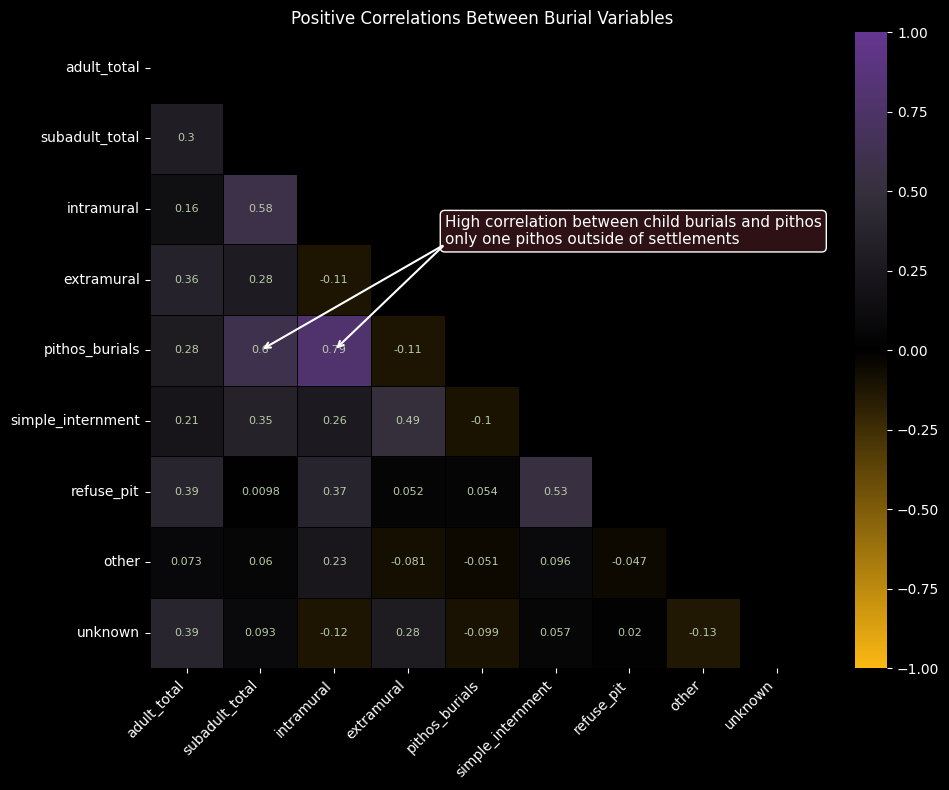

In [24]:
#from cycler import cycler
#with plt.style.context('dark_background'):
    #plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mask = np.zeros_like(corr, dtype=bool)

# mask duplicate triangle (upper half)
mask |= np.triu(np.ones_like(corr, dtype=bool))

# I was using a bunch of masks here to hide negatives/values resulting from mutually exclusive relationships
##got rid of them so that the data could stand clearly


from matplotlib.colors import Normalize

##AND NORMALIZE
#norm = Normalize(vmin=0, vmax = corr.where(~mask).max().max())

with plt.style.context("dark_background"):
    #plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
    fig, ax = plt.subplots(figsize=(10,8))

    sns.heatmap(
        corr,
        mask=mask,
        cmap=husky_cmap,
        #norm=norm,
        vmin=-1,
        vmax=1,
        annot=True,
        annot_kws={"size": 8, "color": "#B8CCA7"},
        #fmt=".2f",
        linecolor='k',
        linewidths=0.5
        ,ax=ax
    )

    #labels (cells?) to coords
    row = corr.index.get_loc('pithos_burials')
    col = corr.columns.get_loc('intramural')

   # coordinates of the text box
    text_x = col + 2
    text_y = row - 1
    
    # draw the text box once
    ax.text(
        text_x,
        text_y,
        'High correlation between child burials and pithos\nonly one pithos outside of settlements',
        fontsize=11,
        color='white',
        bbox=dict(boxstyle='round,pad=0.3', fc='#2D1115', ec='white')
    )
    
    # arrow 1 → intramural/pithos cell
    row1 = corr.index.get_loc('pithos_burials')
    col1 = corr.columns.get_loc('intramural')
    
    ax.annotate(
           '',
          xy=(col1+0.5, row1+0.5),
         xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle='->', color='white', lw=1.5)
    )
    
    # arrow 2 → subadult/pithos cell
    row2 = corr.index.get_loc('pithos_burials')
    col2 = corr.columns.get_loc('subadult_total')
    
    ax.annotate(
        '',
        xy=(col2+0.5, row2+0.5),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle='->', color='white', lw=1.5)
    )
    
    #adding 
    plt.title("Positive Correlations Between Burial Variables")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


## Alternatively...

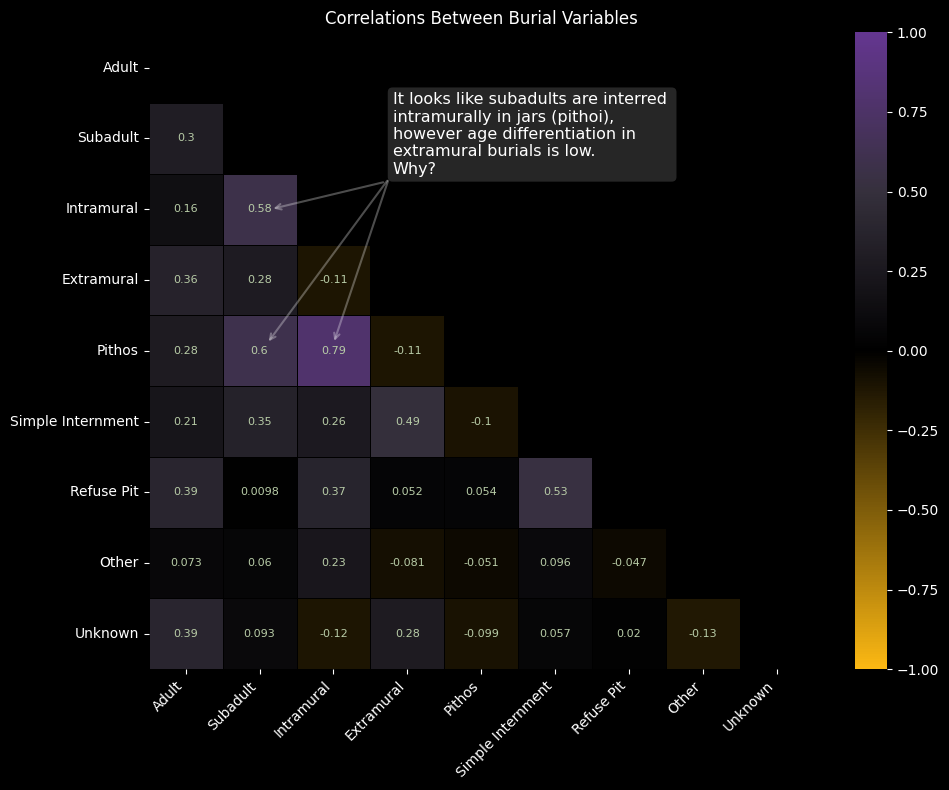

In [91]:
#from cycler import cycler
#with plt.style.context('dark_background'):
    #plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mask = np.zeros_like(corr, dtype=bool)

# mask duplicate triangle (upper half)
mask |= np.triu(np.ones_like(corr, dtype=bool))

# I was using a bunch of masks here to hide negatives/values resulting from mutually exclusive relationships
##got rid of them so that the data could stand clearly


from matplotlib.colors import Normalize

##AND NORMALIZE
#norm = Normalize(vmin=0, vmax = corr.where(~mask).max().max())

with plt.style.context("dark_background"):
    #plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
    fig, ax = plt.subplots(figsize=(10,8))

    sns.heatmap(
        corr,
        mask=mask,
        cmap=husky_cmap,
        #norm=norm,
        vmin=-1,
        vmax=1,
        annot=True,
        annot_kws={"size": 8, "color": "#B8CCA7"},
        #fmt=".2f",
        linecolor='k',
        linewidths=0.5
        ,ax=ax
    )
##ANNOTATION STATION (what your formation?)
    #labels (cells?) to coords
    row = corr.index.get_loc('pithos_burials')
    col = corr.columns.get_loc('intramural')

   # coordinates of the text box
    text_x = col + 1.3
    text_y = row - 2
    
    # draw the text box once
    ax.text(
        text_x,
        text_y,
        'It looks like subadults are interred \nintramurally in jars (pithoi), \nhowever age differentiation in \nextramural burials is low. \nWhy?',
        fontsize=11.5,
        color='white',
        bbox=dict(boxstyle='round,pad=0.3', #fc='#2D1115', ec='white')
                  fc='grey',
                  ec='none',
                  alpha=0.3)
    )
    
    # arrow 1 → intramural/pithos cell
    row1 = corr.index.get_loc('pithos_burials')
    col1 = corr.columns.get_loc('intramural')
    
    ax.annotate(
        '',
        xy=(col1+0.5, row1+0.4),
        xytext=(text_x-0.05, text_y+0.065),
        arrowprops=dict(arrowstyle='->', color='white', alpha=0.3, lw=1.5)
    )
    
    # arrow 2 → subadult/pithos cell
    row2 = corr.index.get_loc('pithos_burials')
    col2 = corr.columns.get_loc('subadult_total')
    
    ax.annotate(
        '',
        xy=(col2+0.6, row2+0.4),
        xytext=(text_x-0.05, text_y+0.065),
        arrowprops=dict(arrowstyle='->', color='white', alpha=0.3, lw=1.5)
    )

        # arrow 3 → subadult/intramural cell
    row2 = corr.index.get_loc('intramural')
    col2 = corr.columns.get_loc('subadult_total')
    
    ax.annotate(
        '',
        xy=(col2+0.65, row2+0.5),
        xytext=(text_x-0.09, text_y+0.11),
        arrowprops=dict(arrowstyle='->', color='white', alpha=0.3, lw=1.5)
    )


    ##TICKS AND LABELS
    ax.set_xticklabels(['Adult',
                        'Subadult',
                        'Intramural',
                        'Extramural',
                        'Pithos',
                        'Simple Internment',
                        'Refuse Pit',
                        'Other',
                        'Unknown'])    # Custom xtick labels
    
    ax.set_yticklabels(['Adult',
                        'Subadult',
                        'Intramural',
                        'Extramural',
                        'Pithos',
                        'Simple Internment',
                        'Refuse Pit',
                        'Other',
                        'Unknown'])    # Custom xtick labels

##WHATEVER IS LEFTOVER
    #adding formatting
    plt.title("Correlations Between Burial Variables")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('correlations_burial_variables.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
#my small change